In [21]:
import zipfile

with zipfile.ZipFile('archive (3).zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [22]:
import os

for root, dirs, files in os.walk('dataset'):
    print(root)

dataset
dataset/Sign-language-digits-dataset


In [23]:
for root, dirs, files in os.walk('dataset'):
    for file in files:
        print(file)

X.npy
Y.npy
X.npy
Y.npy


In [24]:
import numpy as np

X = np.load('dataset/Sign-language-digits-dataset/X.npy')

Y = np.load('dataset/Sign-language-digits-dataset/Y.npy')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [25]:
print(X.shape)
print(Y.shape)

(2062, 64, 64)
(2062, 10)


In [26]:
X_zero = X[204:409]
X_one = X[822:1027]

y_zero = np.zeros(len(X_zero))
y_one = np.ones(len(X_one))

In [27]:
X_data = np.concatenate((X_zero, X_one), axis=0)

y_data = np.concatenate((y_zero, y_one), axis=0)

In [28]:
X_data = X_data.reshape(X_data.shape[0], -1)

print(X_data.shape)

(410, 4096)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.svm import SVC

model = SVC(kernel='linear')

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.975609756097561


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98        45
         1.0       0.95      1.00      0.97        37

    accuracy                           0.98        82
   macro avg       0.97      0.98      0.98        82
weighted avg       0.98      0.98      0.98        82



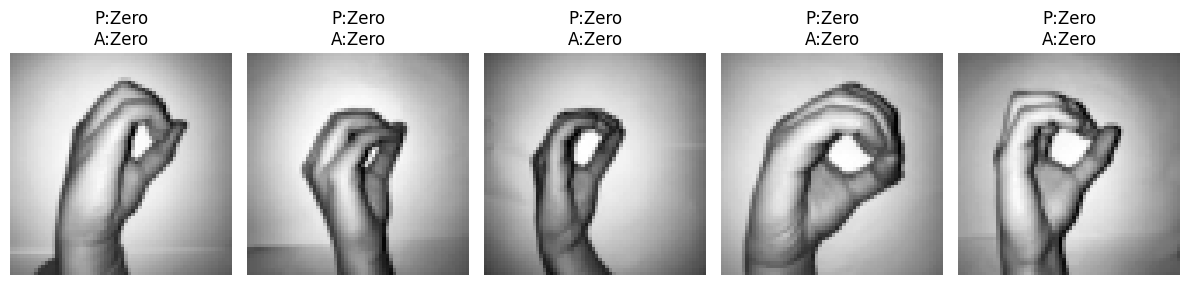

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(5):

    plt.subplot(1,5,i+1)

    image = X_test[i].reshape(64,64)

    plt.imshow(image, cmap='gray')

    actual = "One" if y_test[i] else "Zero"

    predicted = "One" if y_pred[i] else "Zero"

    plt.title(f"P:{predicted}\nA:{actual}")

    plt.axis('off')

plt.tight_layout()

plt.show()

Conclusion:
This project demonstrates a Hand Gesture Recognition system using Support Vector Machine (SVM).

The model successfully classifies hand gesture images using image preprocessing and supervised machine learning techniques.